# Champion vs challenger — journée du 30/07/2026

**Question.** Le challenger (features de température prévue à l'heure cible)
fait-il mieux que le champion sur la prévision réellement émise le 29/07 à 23 h ?

**Protocole.** Origine = **23 h heure de Paris, la veille du jour évalué**.

**Fuseau — deux points distincts, tous deux structurants.**

1. *L'origine est définie en heure locale, pas en UTC.* `forecast_daily_dag.py`
   fixe `ORIGIN_HOUR_PARIS = 23` et convertit ensuite en UTC. En été cela donne
   21 h UTC, **en hiver 22 h UTC** : la valeur UTC change, la définition non.
   Le notebook la **dérive** donc au lieu de la coder en dur, et vérifie qu'elle
   tombe sur une prévision réellement stockée.
2. *Le stockage est en UTC, l'affichage en local.* Le calcul reste en UTC naïf ;
   seul l'affichage est converti, avec la convention de `streamlit_app/data.py`.
   Sans cela l'horizon 1 apparaîtrait « 29/07 22h » ici et « 30/07 00h » sur le
   dashboard, pour la même heure. Le tableau garde les deux colonnes : l'heure
   locale pour recouper avec l'écran, l'heure UTC pour remonter à la ligne en base.

| série | provenance |
|---|---|
| champion | **prévision stockée en base**, telle qu'émise en production |
| RTE (J-1) | **prévision stockée en base**, récupérée via l'API RTE |
| réalisé | observations RTE |
| challenger | **recalculé** à la même origine — c'est le seul modèle qui ne tournait pas ce soir-là |

On ne rejoue donc ni le champion ni RTE : leurs chiffres sont ceux de la
production. C'est aussi ce qui rend ce notebook directement comparable à la
carte KPI du dashboard.

**Le challenger est reconstruit avec la prévision de température archivée à
échéance J-1** — celle dont on disposait la veille, jamais l'observé du 30/07.
En production il aurait eu une prévision plus fraîche (le run du jour), donc
cette reconstruction le désavantage légèrement plutôt que l'inverse.

---

## Avertissement de lecture, à ne pas sauter

**Une journée ne démontre pas qu'un modèle est meilleur qu'un autre.** C'est
exactement le raisonnement qui a lancé cette investigation : la carte KPI affiche
le gain vs RTE sur une seule origine, et ce chiffre a oscillé entre −122 % et
+58 % en cinq jours **sans qu'aucune capacité du modèle ne change**.

Ce notebook est une **illustration**, pas une preuve. La preuve est le backtest
à origine glissante sur six mois hors-échantillon (567 origines de production),
rappelé en conclusion.

In [1]:
import os
import sys
import warnings
from datetime import date, datetime, time, timedelta
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator

# Racine du projet, que le notebook soit lancé depuis `notebooks/` ou la racine.
_ROOT = os.getcwd()
while not os.path.isdir(os.path.join(_ROOT, "pipeline_prevision")):
    _PARENT = os.path.dirname(_ROOT)
    if _PARENT == _ROOT:
        raise RuntimeError("Racine du projet introuvable depuis " + os.getcwd())
    _ROOT = _PARENT
sys.path.insert(0, _ROOT)
os.chdir(_ROOT)
warnings.filterwarnings("ignore")

from pipeline_prevision.db import get_observations
from pipeline_prevision.db.config import get_engine
from pipeline_prevision.utils.main_utils.utils import load_object
from pipeline_prevision.utils.main_utils.feature_engineering import (
    HORIZON_MAX, build_origin_feature_frame, build_series_by_target,
)
from pipeline_prevision.utils.ml_utils.model.local_forecaster import (
    _direct_prediction, get_anchor,
)
from pipeline_prevision.utils.main_utils.prevision_temperature_france import (
    archive_prevision_france,
)

# --- Origine : DÉRIVÉE, jamais codée en dur ---------------------------------
# L'origine n'est pas « 21h UTC » : elle est DÉFINIE comme 23 h heure de Paris la
# veille du jour prévu (`ORIGIN_HOUR_PARIS` dans `dags/forecast_daily_dag.py`,
# fonction `_origine_visee`). 21h UTC n'en est que la représentation d'été — en
# hiver la même origine vaut 22h UTC. Écrire `pd.Timestamp("2026-07-29 21:00")`
# reviendrait à figer une valeur dérivée : ce notebook rejoué en janvier viserait
# la mauvaise heure sans que rien ne le signale.
#
# On ne peut pas importer le DAG (il charge `airflow` à l'import, absent de ce
# venv), donc on rejoue son calcul avec sa constante, et on VÉRIFIE ensuite que
# l'origine obtenue correspond bien à une prévision réellement stockée.
PARIS = ZoneInfo("Europe/Paris")
ORIGIN_HOUR_PARIS = 23          # = dags/forecast_daily_dag.py
JOUR_PREVU = date(2026, 7, 30)  # la journée évaluée, en date locale


def origine_utc(jour_prevu: date) -> pd.Timestamp:
    """23 h Paris de la veille -> horodatage UTC naïf (convention de la base)."""
    veille = jour_prevu - timedelta(days=1)
    locale = datetime.combine(veille, time(ORIGIN_HOUR_PARIS), tzinfo=PARIS)
    return pd.Timestamp(locale.astimezone(ZoneInfo("UTC")).replace(tzinfo=None))


ORIGINE = origine_utc(JOUR_PREVU)
CIBLE = "consommation_totale"
CIBLES = pd.date_range(ORIGINE + pd.Timedelta(hours=1), periods=HORIZON_MAX, freq="h")

# --- Fuseau : calcul en UTC, affichage en heure locale -----------------------
# Tout le pipeline stocke en UTC naïf, mais le dashboard Streamlit affiche en
# heure locale (`streamlit_app/data.py`, helper `_to_local`). Sans cette
# conversion, l'horizon 1 s'afficherait « 29/07 22h » ici et « 30/07 00h » sur le
# dashboard : les deux vues deviendraient impossibles à recouper alors qu'elles
# portent sur les mêmes chiffres. On ne convertit QUE pour l'affichage — index,
# jointures et métriques restent en UTC naïf.
DISPLAY_TZ = os.getenv("DISPLAY_TZ", "Europe/Paris")


def en_local(index):
    """UTC naïf -> fuseau d'affichage, naïf (même convention que le dashboard)."""
    idx = pd.DatetimeIndex(pd.to_datetime(index))
    if idx.tz is None:
        idx = idx.tz_localize("UTC")
    return idx.tz_convert(DISPLAY_TZ).tz_localize(None)


print(f"Fuseau d'affichage : {DISPLAY_TZ}")
print(f"Origine  {ORIGINE} UTC  =  {en_local([ORIGINE])[0]:%d/%m %Hh} heure locale")
print(f"Cibles   {en_local(CIBLES)[0]:%d/%m %Hh} -> {en_local(CIBLES)[-1]:%d/%m %Hh} heure locale")

# Palette validée (validate_palette.js, mode light, --pairs all : tout passe).
# Le réalisé porte l'encre primaire et non une couleur de série : c'est la
# référence, pas un concurrent.
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
C_CHAMPION, C_CHALLENGER, C_RTE = "#2a78d6", "#eb6834", "#1baf7a"
POS, NEG = "#2a78d6", "#e34948"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

Fuseau d'affichage : Europe/Paris
Origine  2026-07-29 21:00:00 UTC  =  29/07 23h heure locale
Cibles   30/07 00h -> 30/07 23h heure locale


## 1. Ce qui est déjà en base : champion, RTE, réalisé

In [2]:
def forecast_stocke(variable, origin=None):
    """Prévision telle qu'elle a été enregistrée par le pipeline."""
    sql = ("SELECT target_ts, y_pred, model_version FROM forecasts "
           "WHERE variable = %(v)s AND target_ts > %(a)s AND target_ts <= %(b)s")
    params = {"v": variable, "a": ORIGINE, "b": CIBLES[-1]}
    if origin is not None:
        sql += " AND origin_ts = %(o)s"
        params["o"] = origin
    df = pd.read_sql(sql + " ORDER BY target_ts", get_engine(), params=params,
                     parse_dates=["target_ts"]).set_index("target_ts")
    return df


champion_df = forecast_stocke(CIBLE, origin=ORIGINE)
rte_df = forecast_stocke("consommation_totale_rte")
obs = get_observations().sort_index()
reel = pd.to_numeric(obs[CIBLE], errors="coerce").reindex(CIBLES)

# Garde-fou : l'origine dérivée doit correspondre à une prévision réellement
# émise. Si la dérivation dérivait (changement d'heure, constante modifiée dans
# le DAG), on tomberait sur 0 point plutôt que de comparer en silence des séries
# décalées d'une heure.
assert not champion_df.empty, (
    f"aucune prévision champion stockée à l'origine dérivée {ORIGINE} — "
    "la définition de l'origine a-t-elle changé dans forecast_daily_dag.py ?")

print(f"champion   : {len(champion_df)} points · version "
      f"{champion_df['model_version'].iloc[0]} · origine {ORIGINE} (stockée)")
print(f"RTE (J-1)  : {len(rte_df)} points (stockée)")
print(f"réalisé    : {int(reel.notna().sum())} / {HORIZON_MAX} heures publiées "
      f"(dernière observation {obs.index.max()})")

champion   : 24 points · version sha256:6568b5d26de8 · origine 2026-07-29 21:00:00 (stockée)
RTE (J-1)  : 24 points (stockée)
réalisé    : 19 / 24 heures publiées (dernière observation 2026-07-30 16:00:00)


## 2. Le seul calcul : la prévision du challenger à la même origine

Les observations sont tranchées à l'origine — aucune donnée postérieure n'entre
dans les features. La température prévue vient de l'archive J-1.

In [3]:
obs_origine = obs.loc[:ORIGINE]
print(f"Observations vues par le challenger : jusqu'à {obs_origine.index.max()}")

temp_prev = archive_prevision_france(
    (ORIGINE - pd.Timedelta(days=3)).to_pydatetime(),
    (ORIGINE + pd.Timedelta(hours=HORIZON_MAX + 1)).to_pydatetime(), lead_jours=1)

composite = load_object(os.path.join("candidate_models", "model.pkl"))
entry = composite[CIBLE]
cols, prefix = entry["feature_columns"], entry["prefix"]

temp = pd.to_numeric(obs_origine["temp_fr_om"], errors="coerce")
temp.name = "temp_fr_om"
cadre, _ = build_origin_feature_frame(
    build_series_by_target(obs_origine), temp, CIBLE, temp_prev=temp_prev)

ligne = cadre.loc[[ORIGINE]]
manquantes = [c for c in cols if ligne[c].isna().any()]
assert not manquantes, f"features NaN à l'origine : {manquantes[:5]}"

challenger = pd.Series(
    [float(_direct_prediction(
        entry["models"][h], entry["alphas"][h], entry["seasonal_weights"][h],
        ligne[cols], h, prefix, f"{prefix}_delta_1", get_anchor(entry, h))[0])
     for h in range(1, HORIZON_MAX + 1)], index=CIBLES)
del composite

pred = pd.DataFrame({
    "réalisé": reel,
    "champion": champion_df["y_pred"].reindex(CIBLES),
    "challenger": challenger,
    "RTE (J-1)": rte_df["y_pred"].reindex(CIBLES),
})
(pred / 1000).round(2)

Observations vues par le challenger : jusqu'à 2026-07-29 21:00:00


,réalisé,champion,challenger,RTE (J-1)
2026-07-29 22:00:00,44.65,45.25,44.70,45.34
2026-07-29 23:00:00,42.21,42.04,41.52,42.86
2026-07-30 00:00:00,39.99,40.48,39.86,40.22
2026-07-30 01:00:00,38.03,38.46,37.81,38.10
2026-07-30 02:00:00,37.61,37.48,37.09,37.46
2026-07-30 03:00:00,38.76,37.63,37.44,38.54
2026-07-30 04:00:00,40.70,39.80,39.17,40.24
2026-07-30 05:00:00,42.80,42.63,42.05,42.58
2026-07-30 06:00:00,46.01,45.94,45.26,45.18
2026-07-30 07:00:00,47.98,48.34,48.11,47.28


## 3. La journée

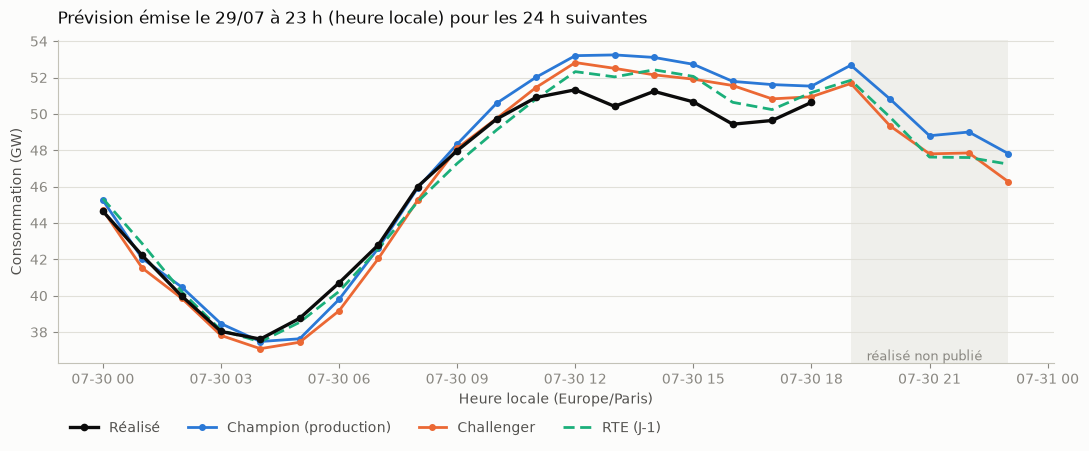

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.6))
x = en_local(pred.index)          # affichage en heure locale, comme le dashboard

ax.plot(x, pred["réalisé"] / 1000, color=INK, lw=2.4, marker="o", ms=4.5,
        zorder=5, label="Réalisé")
ax.plot(x, pred["champion"] / 1000, color=C_CHAMPION, lw=2, marker="o", ms=4,
        label="Champion (production)")
ax.plot(x, pred["challenger"] / 1000, color=C_CHALLENGER, lw=2, marker="o", ms=4,
        label="Challenger")
ax.plot(x, pred["RTE (J-1)"] / 1000, color=C_RTE, lw=2, ls=(0, (4, 2)),
        label="RTE (J-1)")

trous = x[pred["réalisé"].isna().to_numpy()]
if len(trous):
    ax.axvspan(trous[0], x[-1], color=GRID, alpha=0.45, lw=0, zorder=0)
    ax.text(trous[0] + pd.Timedelta(hours=0.3), ax.get_ylim()[0],
            " réalisé non publié", color=MUTED, fontsize=9, va="bottom")

ax.set_ylabel("Consommation (GW)", color=INK_2)
ax.set_xlabel(f"Heure locale ({DISPLAY_TZ})", color=INK_2)
ax.set_title("Prévision émise le 29/07 à 23 h (heure locale) pour les 24 h suivantes",
             color=INK, fontsize=12, loc="left", pad=12)
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.legend(frameon=False, ncol=4, loc="upper left", labelcolor=INK_2,
          bbox_to_anchor=(0, -0.14))
ax.grid(axis="x", visible=False)
fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

## 4. Métriques par horizon

Restreint aux horizons dont le réalisé est publié. `gain` = réduction de MAE du
challenger par rapport au champion ; positif = le challenger fait mieux.

In [5]:
MODELES = ["champion", "challenger", "RTE (J-1)"]
evalues = pred.dropna(subset=["réalisé"]).copy()

tableau = pd.DataFrame({
    "horizon_h": range(1, len(evalues) + 1),
    # Heure locale, comme le dashboard — cf. `en_local`. L'heure UTC est gardée
    # à côté : c'est elle qui indexe la base, donc la seule qui permette de
    # remonter à la ligne exacte en cas de vérification.
    "heure_cible_locale": en_local(evalues.index).strftime("%d/%m %Hh"),
    "heure_cible_UTC": evalues.index.strftime("%d/%m %Hh"),
    "réalisé_GW": (evalues["réalisé"] / 1000).values,
})
for m in MODELES:
    tableau[f"err_{m}_MW"] = (evalues[m] - evalues["réalisé"]).abs().values
tableau["gain_vs_champion_%"] = 100 * (
    tableau["err_champion_MW"] - tableau["err_challenger_MW"]) / tableau["err_champion_MW"]

tableau.set_index("horizon_h").round(1)

,heure_cible_locale,heure_cible_UTC,réalisé_GW,err_champion_MW,err_challenger_MW,err_RTE (J-1)_MW,gain_vs_champion_%
horizon_h,,,,,,,
1,30/07 00h,29/07 22h,44.6,601.2,54.5,695.5,90.9
2,30/07 01h,29/07 23h,42.2,168.3,691.2,650.5,-310.6
3,30/07 02h,30/07 00h,40.0,495.7,122.2,239.8,75.3
4,30/07 03h,30/07 01h,38.0,430.2,217.0,68.0,49.6
5,30/07 04h,30/07 02h,37.6,134.7,527.9,151.0,-291.9
6,30/07 05h,30/07 03h,38.8,1127.4,1318.3,221.0,-16.9
7,30/07 06h,30/07 04h,40.7,905.5,1533.4,466.0,-69.3
8,30/07 07h,30/07 05h,42.8,173.4,748.6,224.8,-331.7
9,30/07 08h,30/07 06h,46.0,67.5,746.3,831.2,-1005.7


In [6]:
resume = pd.DataFrame({
    "MAE (MW)": [tableau[f"err_{m}_MW"].mean() for m in MODELES],
    "WAPE (%)": [100 * tableau[f"err_{m}_MW"].sum() / evalues["réalisé"].sum()
                 for m in MODELES],
    "biais moyen (MW)": [(evalues[m] - evalues["réalisé"]).mean() for m in MODELES],
    "erreur max (MW)": [tableau[f"err_{m}_MW"].max() for m in MODELES],
}, index=MODELES)
resume["gain MAE vs champion (%)"] = 100 * (
    resume.loc["champion", "MAE (MW)"] - resume["MAE (MW)"]) / resume.loc["champion", "MAE (MW)"]
resume["gain MAE vs RTE (%)"] = 100 * (
    resume.loc["RTE (J-1)", "MAE (MW)"] - resume["MAE (MW)"]) / resume.loc["RTE (J-1)", "MAE (MW)"]

print(f"Sur {len(tableau)} horizons évalués — à comparer à la carte KPI du dashboard\n")
resume.round(1)

Sur 19 horizons évalués — à comparer à la carte KPI du dashboard



,MAE (MW),WAPE (%),biais moyen (MW),erreur max (MW),gain MAE vs champion (%),gain MAE vs RTE (%)
champion,1068.8,2.3,797.6,2831.1,0.0,-62.5
challenger,844.5,1.8,223.0,2128.5,21.0,-28.4
RTE (J-1),657.6,1.4,311.6,1623.5,38.5,0.0


## 5. Gain par horizon

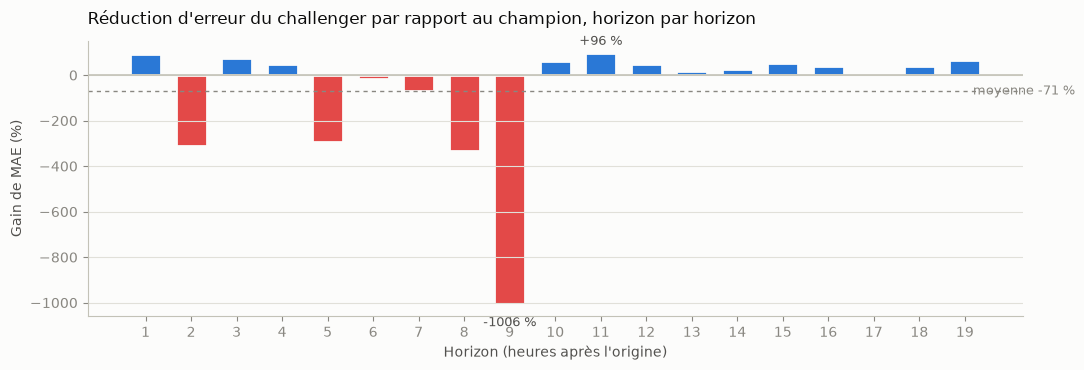

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.8))
g = tableau["gain_vs_champion_%"].to_numpy()
h = tableau["horizon_h"].to_numpy()

ax.bar(h, g, color=[POS if v >= 0 else NEG for v in g], width=0.68,
       edgecolor=SURFACE, linewidth=2)
ax.axhline(0, color=AXIS, lw=1.2)
ax.set_xlabel("Horizon (heures après l'origine)", color=INK_2)
ax.set_ylabel("Gain de MAE (%)", color=INK_2)
ax.set_title("Réduction d'erreur du challenger par rapport au champion, horizon par horizon",
             color=INK, fontsize=12, loc="left", pad=12)
ax.set_xticks(h)
ax.grid(axis="x", visible=False)

# Étiquettes directes sur les extrêmes seulement — jamais sur chaque barre.
for i in (int(np.argmax(g)), int(np.argmin(g))):
    ax.annotate(f"{g[i]:+.0f} %", (h[i], g[i]), textcoords="offset points",
                xytext=(0, 6 if g[i] >= 0 else -16), ha="center",
                color=INK_2, fontsize=9)
moyen = g.mean()
ax.axhline(moyen, color=MUTED, lw=1, ls=(0, (3, 3)))
ax.text(h[-1], moyen, f"  moyenne {moyen:+.0f} %", color=MUTED, fontsize=9, va="center")
plt.tight_layout()
plt.show()

## Conclusion

### Ce que dit la journée

Les chiffres du tableau de synthèse ci-dessus sont ceux de la production pour le
champion et RTE — ils doivent coïncider avec la carte KPI du dashboard.

Le gain par horizon est **très dispersé**. Cette dispersion sur une seule journée
est l'illustration directe de l'avertissement du début : à cette échelle, on lit
du bruit, pas une capacité.

### Ce qui départage réellement

**Une journée ne suffit pas à départager deux modèles** : sur ~18 points,
l'intervalle de confiance d'un écart de MAE couvre largement zéro. Un jour
favorable ne prouve rien, un jour défavorable ne réfuterait rien.

Ce qui départage, c'est le backtest à origine glissante sur la fenêtre
hors-échantillon commune (2026-01-18 → 2026-07-26), aux heures d'origine de
production, soit **567 origines** :

| régime météo | origines | champion | challenger | gain |
|---|---|---|---|---|
| stable (<2 °C) | 381 | 966 MW | 817 MW | +15,4 % |
| transition (2-4 °C) | 175 | 1 077 MW | 914 MW | +15,1 % |
| bascule (>4 °C) | 11 | 1 172 MW | 971 MW | +17,2 % |
| **tous** | **567** | **1 004 MW** | **850 MW** | **+15,4 %** |

IC95 de l'écart global : **[−200,8, −112,3] MW** — il ne croise pas zéro, le gain
est significatif.

**Deux réserves qui tiennent.** Le gain est *diffus* et non concentré sur les
bascules thermiques comme attendu ; et la corrélation entre le biais et la
bascule ne s'est pas effondrée (+0,382 → +0,392). Un modèle d'ablation
(température Open-Meteo en origine, **sans** les features de prévision) doit
encore déterminer si le gain vient des features de prévision, ou de la bascule
de source et du réentraînement.